# 🚗 Car Price Prediction — Azerbaijan Market
Predicting used car prices from turbo.az listings using Machine Learning.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer  
from sklearn.preprocessing import OrdinalEncoder, StandardScaler   
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
current=datetime.now().year


## 2. Load Data

In [4]:
df1 = pd.read_csv("turbo-az-2022- 1-ci-hisse.csv")
df2 = pd.read_csv("turbo-az-2022-2 ci-hisse.csv")
df3 = pd.read_csv("turbo-az-2022-3 cu hisse.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)
print("Shape:", df.shape)
df.head(5)


Shape: (31879, 22)


,ban_novu,buraxilis_ili,city,diger_gostericiler,image,is_new,link,marka,model,muherrik,...,price_currency,price_value,reng,seller_name,seller_phone,shop_contact_list,shop_name,suret_qutusu,yanacaq_novu,yurus
0,Sedan,2001,Bakı,"Yüngül lehimli disklər,ABS,Lyuk,Yağış sensoru,...",https://turbo.azstatic.com/uploads/full/2022%2...,Xeyr,https://turbo.az/autos/6783430-bmw-745,BMW,745,4.4 L,...,AZN,12 900,Qara,NaN,NaN,(050) 555-61-61,"Avtosalon ""Auto Store""",Avtomat,Benzin,315 000 km
1,Sedan,1999,Bakı,"Yüngül lehimli disklər,ABS,Lyuk,Yağış sensoru,...",https://turbo.azstatic.com/uploads/full/2022%2...,Xeyr,https://turbo.az/autos/6657726-mercedes-c-230,Mercedes,C 230,2.3 L,...,AZN,11 200,Qara,Emil,(055) 500-49-49,NaN,NaN,Avtomat,Benzin,239 000 km
2,Sedan,2013,Bakı,"Yüngül lehimli disklər,ABS,Lyuk,Mərkəzi qapanm...",https://turbo.azstatic.com/uploads/full/2022%2...,Xeyr,https://turbo.az/autos/6883755-faw-besturn-b50,FAW,Besturn B50,1.6 L,...,AZN,10 500,Tünd qırmızı,Eflatun,(050) 338-09-59,NaN,NaN,Avtomat,Benzin,172 000 km
3,Sedan,2013,Sumqayıt,"Yüngül lehimli disklər,ABS,Lyuk,Yağış sensoru,...",https://turbo.azstatic.com/uploads/full/2022%2...,Xeyr,https://turbo.az/autos/6754385-brilliance-h-530,Brilliance,H 530,1.6 L,...,AZN,13 400,Qara,Natiq,(010) 216-38-58,NaN,NaN,Avtomat,Benzin,92 000 km
4,Sedan,1995,Bakı,"Yüngül lehimli disklər,ABS,Mərkəzi qapanma,Kon...",https://turbo.azstatic.com/uploads/full/2022%2...,Xeyr,https://turbo.az/autos/6883757-mercedes-c-220,Mercedes,C 220,2.2 L,...,AZN,8 800,Yaş Asfalt,Elvin,(051) 833-44-44,NaN,NaN,Avtomat,Benzin,298 889 km


## 3. Data Cleaning

In [5]:
# Drop irrelevant columns
df.drop(columns=["diger_gostericiler","image","link","seller_name",
                  "seller_phone","shop_contact_list","shop_name","is_new","oturucu"], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Clean numeric columns
df["muherrik"]=df["muherrik"].str.replace(" L","").astype(float)
df["muherrik_gucu"]=df["muherrik_gucu"].str.replace(" a.g.","").astype(float)
df["yurus"]=df["yurus"].str.replace(" km","").str.replace(" ","").astype(float)
df["price_value"]=df["price_value"].str.replace(" ","").astype(float)

# Convert all prices to AZN
rates = {"AZN": 1.0, "$": 1.7, "€": 1.85}
df["price"] = df.apply(lambda r: r["price_value"] * rates[r["price_currency"]], axis=1)
df.drop(columns=["price_value","price_currency"], inplace=True)

# Remove extreme outliers (bottom 0.5% and top 0.5%)
df = df[(df["price"] >= df["price"].quantile(0.005)) &
        (df["price"] <= df["price"].quantile(0.995)) &
        (df["buraxilis_ili"] >= 1990)]

print("Clean shape:", df.shape)


Clean shape: (25375, 12)


## 4. Feature Engineering

In [6]:
# Car age instead of raw year
df["car_age"] =current- df["buraxilis_ili"]
df.drop(columns=["buraxilis_ili"], inplace=True)

# Log-transform price and mileage (both right-skewed)
df["log_price"] = np.log1p(df["price"])
df["log_yurus"] = np.log1p(df["yurus"])


## 5. Exploratory Data Analysis

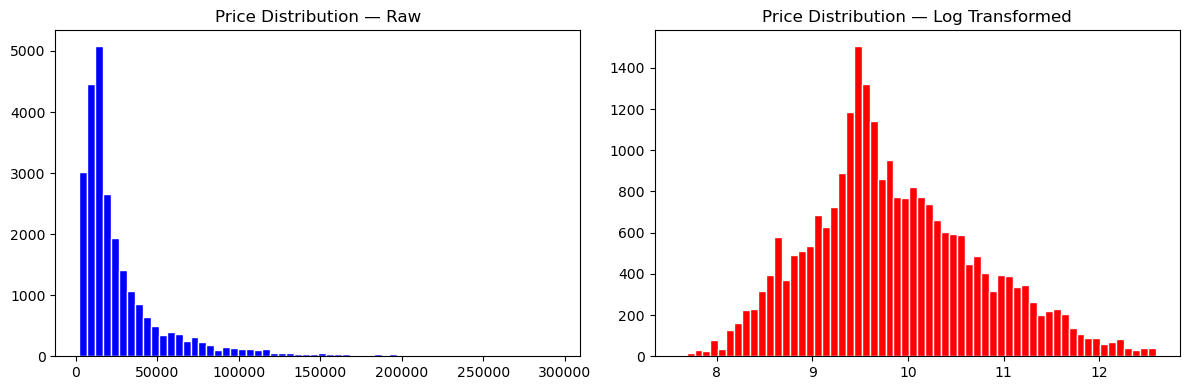

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price"], bins=60, color="blue", edgecolor="white")
axes[0].set_title("Price Distribution — Raw")
axes[1].hist(df["log_price"], bins=60, color="red", edgecolor="white")
axes[1].set_title("Price Distribution — Log Transformed")
plt.tight_layout()
plt.show()


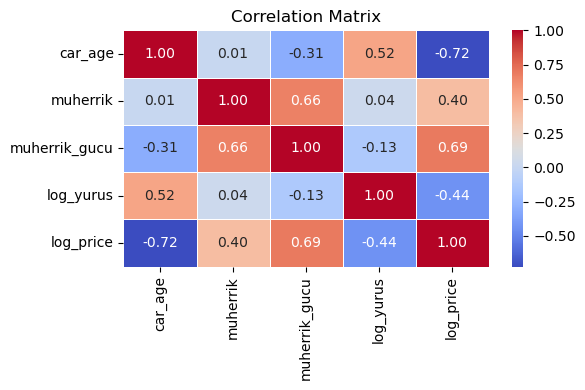

In [8]:
# Correlation
num_cols = ["car_age","muherrik","muherrik_gucu","log_yurus","log_price"]
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


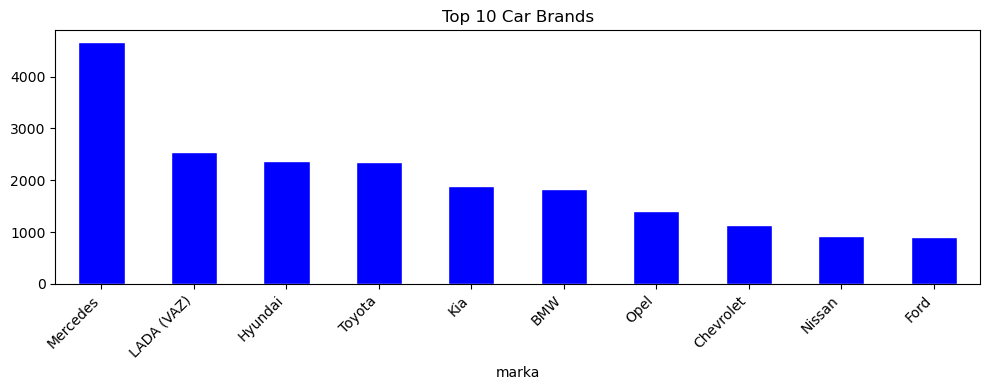

In [9]:
# Top 10 brands
df["marka"].value_counts().head(10).plot(kind="bar", figsize=(10,4), color="blue", edgecolor="white")
plt.title("Top 10 Car Brands")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 6. Train / Test Split

In [10]:
features= ["marka","model","car_age","ban_novu","reng",
            "muherrik","muherrik_gucu","suret_qutusu",
            "yanacaq_novu","log_yurus","city"]

X = df[features]
y = df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")


Train: 20,300  |  Test: 5,075


## 7. Preprocessing Pipeline


In [11]:
cat= ["marka","model","ban_novu","reng","suret_qutusu","yanacaq_novu","city"]
num = ["car_age","muherrik","muherrik_gucu","log_yurus"]

preprocessor = ColumnTransformer([
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),cat),
    ("num", StandardScaler(),num),
])


## 8. Model Training & Evaluation

In [12]:
models = {
    "Ridge Regression"      : Ridge(alpha=10),
    "KNeighbors"            : KNeighborsRegressor(n_neighbors=7, weights="distance"),
    "Decision Tree"         : DecisionTreeRegressor(max_depth=12, min_samples_leaf=5, random_state=42),
    "Random Forest"         : RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    "Gradient Boosting"     : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    "HistGradient Boosting" : HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, max_depth=8, random_state=42),
}

results = []
pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)

    y_pred = np.expm1(pipe.predict(X_test))
    y_true = np.expm1(y_test)

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})
    pipelines[name] = pipe
    print(f"{name:<28} | R²={r2:.4f} | MAE={mae:,.0f} AZN | RMSE={rmse:,.0f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


Ridge Regression             | R²=-125.2714 | MAE=15,131 AZN | RMSE=397,866
KNeighbors                   | R²=0.8658 | MAE=5,049 AZN | RMSE=12,973
Decision Tree                | R²=0.9230 | MAE=4,269 AZN | RMSE=9,823
Random Forest                | R²=0.9554 | MAE=3,116 AZN | RMSE=7,478
Gradient Boosting            | R²=0.9526 | MAE=3,458 AZN | RMSE=7,707
HistGradient Boosting        | R²=0.9559 | MAE=3,352 AZN | RMSE=7,432


,Model,R2,MAE,RMSE
0,HistGradient Boosting,0.955941,3352.355238,7431.950207
1,Random Forest,0.955388,3116.382949,7478.402354
2,Gradient Boosting,0.952615,3457.739595,7707.363976
3,Decision Tree,0.923025,4268.625948,9823.319562
4,KNeighbors,0.865761,5048.795330,12972.522206
5,Ridge Regression,-125.271369,15130.734424,397866.104166


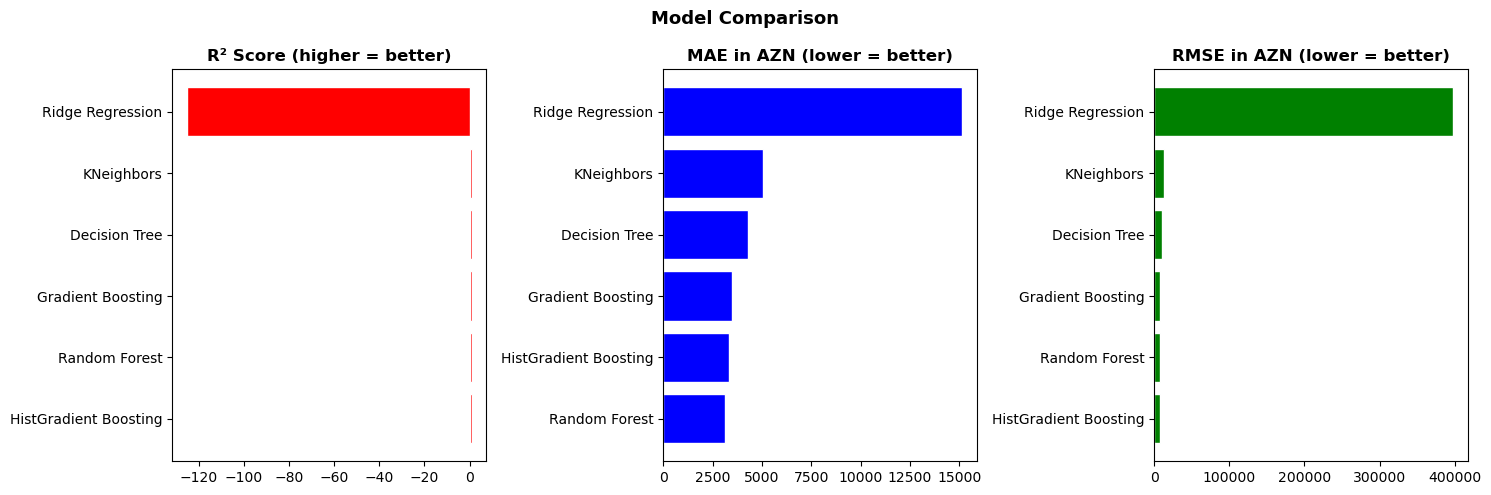

In [13]:
# Model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, title, color) in zip(axes, [
    ("R2",   "R² Score (higher = better)", "red"),
    ("MAE",  "MAE in AZN (lower = better)", "blue"),
    ("RMSE", "RMSE in AZN (lower = better)", "green"),
]):
    sdf = results_df.sort_values(col, ascending=(col != "R2"))
    ax.barh(sdf["Model"], sdf[col], color=color, edgecolor="white")
    ax.set_title(title, fontweight="bold")
plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Feature Importance
Using Permutation Importance — works with all models including HistGradientBoosting.

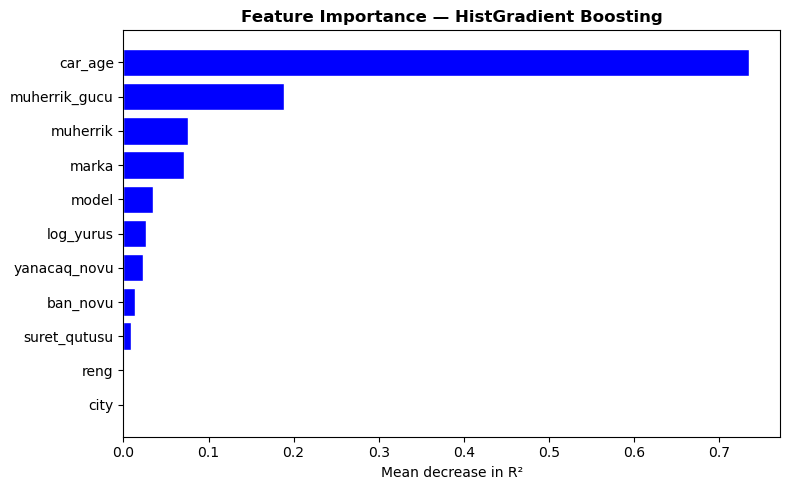

In [14]:
best_name = results_df.iloc[0]["Model"]
best_pipe = pipelines[best_name]

perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

fi_df = pd.DataFrame({"Feature":features, "Importance": perm.importances_mean}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["Feature"], fi_df["Importance"], color="blue", edgecolor="white")
plt.title(f"Feature Importance — {best_name}", fontweight="bold")
plt.xlabel("Mean decrease in R²")
plt.tight_layout()
plt.show()


## 10. Save Model

In [15]:
best_pipe = pipelines[results_df.iloc[0]["Model"]]
joblib.dump(best_pipe, "car_price_model.pkl")
print(f"✓ Model saved: {results_df.iloc[0]['Model']}")
print(f"✓ R²  : {results_df.iloc[0]['R2']:.4f}")
print(f"✓ MAE : {results_df.iloc[0]['MAE']:,.0f} AZN")


✓ Model saved: HistGradient Boosting
✓ R²  : 0.9559
✓ MAE : 3,352 AZN


## 11. Predict New Car

In [16]:
model = joblib.load("car_price_model.pkl")

new_car = pd.DataFrame([{
    "marka"        : "BMW",
    "model"        : "X5",
    "car_age"      : current- 2018,
    "ban_novu"     : "Sedan",
    "reng"         : "Qara",
    "muherrik"     : 2.0,
    "muherrik_gucu": 190,
    "suret_qutusu" : "Avtomat",
    "yanacaq_novu" : "Benzin",
    "log_yurus"    : np.log1p(120_000),
    "city"         : "Bakı",
}])

price = np.expm1(model.predict(new_car)[0])
print(f"Predicted Price : {price:,.0f} AZN  ≈  {price/1.7:,.0f} USD")


Predicted Price : 65,043 AZN  ≈  38,261 USD
